### Import Libraries

In [58]:
import pandas as pd
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import confusion_matrix, precision_score, f1_score, recall_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRFClassifier, XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

### import the dataset

In [25]:
data = pd.read_csv('transport_dataset.csv')
X = data.iloc[:, :-2]
y_class = data["congestion"]
y_reg = data["delay_minutes"]

# Exploratory Data Analysis(EDA)

In [4]:
data.head()

,hour,day_of_week,is_weekend,is_holiday,current_volume,previous_hour_volume,road_capacity,average_speed,rainfall_mm,temperature,event_nearby,accident_reported,road_work,bus_frequency,signal_density,lane_count,population_density,congestion,delay_minutes
0,6,7,0,1,1488,570,1870,27,2,24,0,0,0,19,9,3,10328,0,27.9
1,19,3,0,0,662,1266,1808,66,18,25,1,1,1,8,7,4,9378,1,57.0
2,14,3,0,1,537,1215,893,41,19,22,0,0,1,17,4,4,12046,1,51.2
3,10,1,1,1,1899,1477,1757,16,24,24,0,0,0,28,6,5,10442,1,78.8
4,7,3,1,0,1406,933,1811,59,17,24,0,0,0,24,5,5,2333,1,44.0


In [5]:
print(f"The data contains {data.shape[0]} rows and {data.shape[1]} columns")
print(f"The data contains {data.shape[0]} observations and {data.shape[1]} variables")

The data contains 100 rows and 19 columns
The data contains 100 observations and 19 variables


In [6]:
data.columns

Index(['hour', 'day_of_week', 'is_weekend', 'is_holiday', 'current_volume',
       'previous_hour_volume', 'road_capacity', 'average_speed', 'rainfall_mm',
       'temperature', 'event_nearby', 'accident_reported', 'road_work',
       'bus_frequency', 'signal_density', 'lane_count', 'population_density',
       'congestion', 'delay_minutes'],
      dtype='object')

In [7]:
print(f"The data contains {data.isnull().sum().sum()} missing values")

The data contains 0 missing values


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hour                  100 non-null    int64  
 1   day_of_week           100 non-null    int64  
 2   is_weekend            100 non-null    int64  
 3   is_holiday            100 non-null    int64  
 4   current_volume        100 non-null    int64  
 5   previous_hour_volume  100 non-null    int64  
 6   road_capacity         100 non-null    int64  
 7   average_speed         100 non-null    int64  
 8   rainfall_mm           100 non-null    int64  
 9   temperature           100 non-null    int64  
 10  event_nearby          100 non-null    int64  
 11  accident_reported     100 non-null    int64  
 12  road_work             100 non-null    int64  
 13  bus_frequency         100 non-null    int64  
 14  signal_density        100 non-null    int64  
 15  lane_count            10

In [9]:
data.describe()

,hour,day_of_week,is_weekend,is_holiday,current_volume,previous_hour_volume,road_capacity,average_speed,rainfall_mm,temperature,event_nearby,accident_reported,road_work,bus_frequency,signal_density,lane_count,population_density,congestion,delay_minutes
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,11.850000,4.140000,0.510000,0.580000,1041.270000,1096.560000,1713.980000,41.720000,15.030000,28.330000,0.510000,0.510000,0.45,17.090000,6.790000,3.090000,7938.840000,0.770000,56.641000
std,6.871659,2.054903,0.502418,0.496045,554.378547,487.505448,486.553806,21.309684,8.732217,5.554241,0.502418,0.502418,0.50,7.052609,4.321183,1.429099,3957.398254,0.422953,26.839411
min,0.000000,1.000000,0.000000,0.000000,116.000000,104.000000,811.000000,5.000000,0.000000,20.000000,0.000000,0.000000,0.00,5.000000,1.000000,1.000000,1060.000000,0.000000,0.000000
25%,6.000000,3.000000,0.000000,0.000000,607.250000,755.750000,1297.500000,22.750000,8.000000,23.750000,0.000000,0.000000,0.00,12.000000,3.000000,2.000000,5065.750000,1.000000,37.200000
50%,12.000000,4.000000,1.000000,1.000000,1043.000000,1102.500000,1737.500000,42.500000,16.000000,28.500000,1.000000,1.000000,0.00,16.000000,7.000000,3.000000,7984.500000,1.000000,54.450000
75%,18.000000,6.000000,1.000000,1.000000,1476.000000,1466.000000,2103.000000,61.250000,22.250000,34.000000,1.000000,1.000000,1.00,23.250000,10.250000,4.000000,10865.250000,1.000000,77.425000
max,23.000000,7.000000,1.000000,1.000000,1995.000000,1953.000000,2498.000000,79.000000,29.000000,37.000000,1.000000,1.000000,1.00,29.000000,14.000000,5.000000,14849.000000,1.000000,132.800000


In [10]:
data['congestion'].value_counts()

congestion
1    77
0    23
Name: count, dtype: int64

In [11]:
print(f"Number of uncongested observations: {data['congestion'].value_counts()[0]}")
print(f"Number of congested observations: {data['congestion'].value_counts()[1]}")

Number of uncongested observations: 23
Number of congested observations: 77


### Correlational Analysis
- Higher traffic volume tends to increase congestion.

In [12]:
data.corr()

,hour,day_of_week,is_weekend,is_holiday,current_volume,previous_hour_volume,road_capacity,average_speed,rainfall_mm,temperature,event_nearby,accident_reported,road_work,bus_frequency,signal_density,lane_count,population_density,congestion,delay_minutes
hour,1.000000,-0.298940,-0.109277,-0.199433,-0.199302,-0.127233,0.003534,-0.040712,0.152757,-0.023832,0.095526,-0.120980,0.055123,0.101577,-0.060602,0.019903,0.052753,-0.036318,-0.021868
day_of_week,-0.298940,1.000000,-0.118775,-0.011099,0.171016,0.035595,0.059266,-0.002325,-0.071728,-0.075775,-0.128559,0.057333,-0.130754,-0.101244,0.183077,0.005985,0.263783,-0.043931,0.027220
is_weekend,-0.109277,-0.118775,1.000000,0.098083,0.001423,0.044557,0.080080,-0.099742,0.182969,0.080249,-0.000400,0.119648,0.042220,-0.021637,0.021914,0.146449,-0.270612,0.129769,0.100907
is_holiday,-0.199433,-0.011099,0.098083,1.000000,0.082732,0.017398,0.140586,-0.011238,-0.074016,-0.007846,-0.023507,-0.064038,0.036654,0.085984,-0.018001,-0.003135,-0.033095,-0.079921,-0.058176
current_volume,-0.199302,0.171016,0.001423,0.082732,1.000000,-0.062436,0.082370,0.160886,0.036461,-0.024364,-0.019611,-0.107156,-0.131448,-0.073698,-0.072918,-0.060439,0.136179,0.317114,0.533562
previous_hour_volume,-0.127233,0.035595,0.044557,0.017398,-0.062436,1.000000,-0.156172,-0.013416,0.196670,-0.020665,0.079818,-0.073224,-0.018159,0.185769,-0.056845,0.043205,-0.010992,0.178949,0.101366
road_capacity,0.003534,0.059266,0.080080,0.140586,0.082370,-0.156172,1.000000,0.086592,0.009847,-0.031914,0.025124,-0.045948,-0.310495,-0.099047,-0.114297,0.067393,0.080337,-0.166369,-0.437538
average_speed,-0.040712,-0.002325,-0.099742,-0.011238,0.160886,-0.013416,0.086592,1.000000,0.019207,-0.122189,0.091780,0.145557,-0.021236,-0.045265,-0.013918,0.355407,-0.014156,-0.052046,-0.163215
rainfall_mm,0.152757,-0.071728,0.182969,-0.074016,0.036461,0.196670,0.009847,0.019207,1.000000,-0.055813,-0.033453,-0.104827,0.057028,0.049981,0.108317,-0.073876,-0.059624,0.513322,0.463874
temperature,-0.023832,-0.075775,0.080249,-0.007846,-0.024364,-0.020665,-0.031914,-0.122189,-0.055813,1.000000,0.225038,0.011475,0.120574,-0.106490,0.022276,-0.024140,-0.088667,0.045535,0.136416


<Axes: >

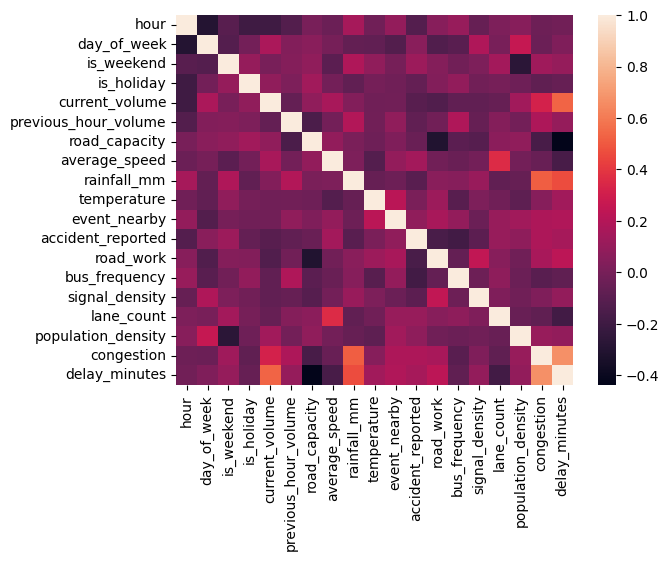

In [13]:
sns.heatmap(data.corr(), annot=False)

### Are most traffic volumes low or high?

<Axes: >

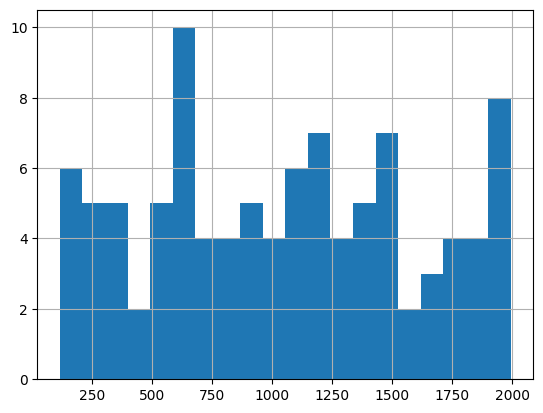

In [14]:
data['current_volume'].hist(bins=20)

<Axes: >

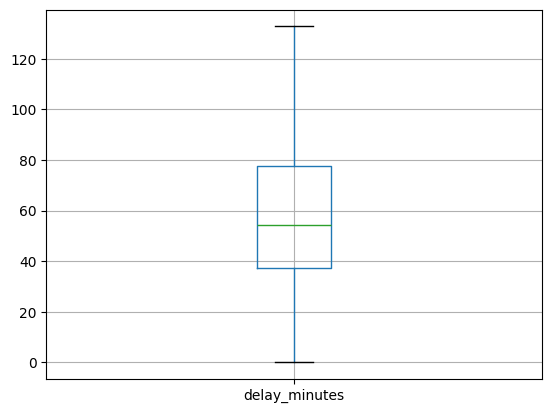

In [15]:
data.boxplot(column='delay_minutes')

### Does delay increase as volume increases?

Text(0.5, 1.0, 'Volume vs Delay')

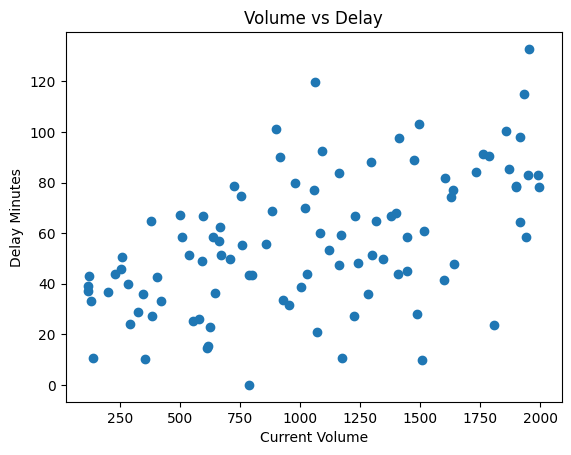

In [16]:
plt.scatter(
    data['current_volume'],
    data['delay_minutes']
)
plt.xlabel('Current Volume')
plt.ylabel('Delay Minutes')
plt.title('Volume vs Delay')

### Which hour experiences the highest traffic volume?

In [17]:
hourly_volume = data.groupby('hour')['current_volume'].agg(['mean', 'sum', 'max'])
hourly_volume.sort_values('mean', ascending=False).head(10)
hourly_volume

,mean,sum,max
hour,,,
0,822.666667,2468,1295
1,1604.400000,8022,1786
2,1266.333333,3799,1952
3,959.666667,5758,1915
4,280.000000,280,280
5,1116.500000,2233,1172
6,1348.166667,8089,1916
7,1304.833333,7829,1990
8,780.500000,3122,1284


Text(0.5, 1.0, 'Hourly Traffic Volume')

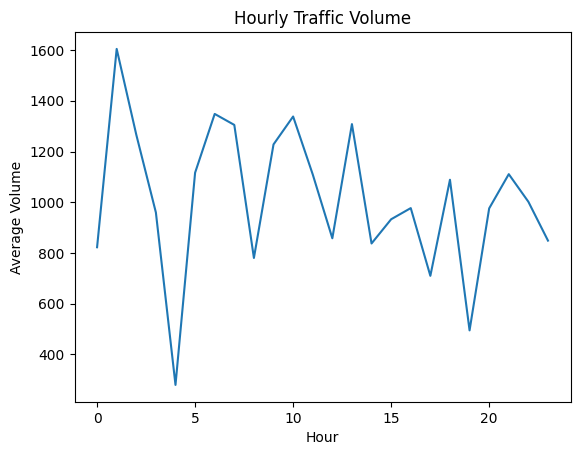

In [18]:
# Visualization
plt.plot(hourly_volume.index, hourly_volume['mean'])
plt.xlabel('Hour')
plt.ylabel('Average Volume')
plt.title('Hourly Traffic Volume')

### Which day has the most congestion?

In [19]:
congestion_by_day = data.groupby('day_of_week')['congestion'].agg(['sum', 'mean'])
congestion_by_day

,sum,mean
day_of_week,,
1,12,0.800000
2,6,0.666667
3,14,0.823529
4,12,0.800000
5,10,0.769231
6,10,0.833333
7,13,0.684211


### Does rainfall increase delays?

C:\Users\HP\AppData\Local\Temp\ipykernel_3472\1222553985.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['rainfall_mm'], bins=5))['delay_minutes'].agg(['mean', 'median', 'count'])


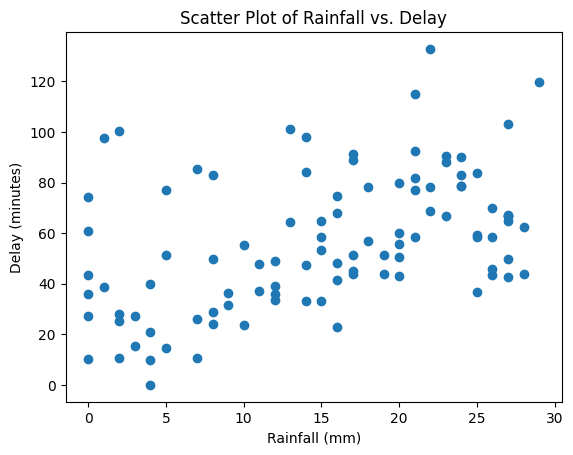

In [63]:
# Correlation
data[['rainfall_mm', 'delay_minutes']].corr()

# Group analysis
data.groupby(pd.cut(data['rainfall_mm'], bins=5))['delay_minutes'].agg(['mean', 'median', 'count'])

# Visualization
plt.scatter(data['rainfall_mm'], data['delay_minutes'])
plt.xlabel('Rainfall (mm)')
plt.ylabel('Delay (minutes)')
plt.title('Scatter Plot of Rainfall vs. Delay')
plt.show()

### Do accident increase delays?

60.73137254901961
52.38367346938775


<Axes: xlabel='accident_reported', ylabel='delay_minutes'>

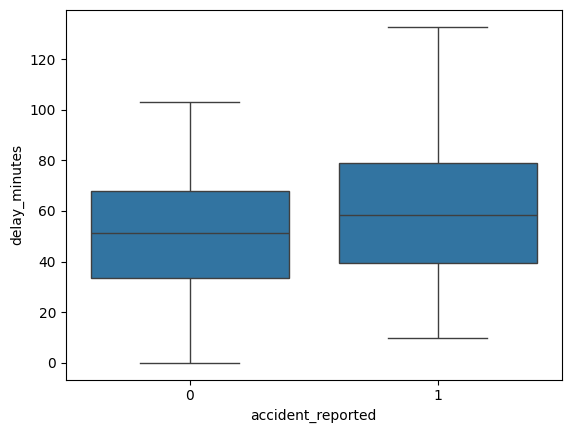

In [21]:
# Compare delays 
data.groupby('accident_reported')['delay_minutes'].agg(['mean', 'median', 'std'])

# Statistical test
print(data[data['accident_reported']==1]['delay_minutes'].mean())
print(data[data['accident_reported']==0]['delay_minutes'].mean())

# Visualization
sns.boxplot(x='accident_reported', y='delay_minutes', data=data)

# Building the Models

### Spliting the model into Training and Test set

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

## Classification Models

In [ ]:
# Decision Tree
classifier = DecisionTreeClassifier(random_state=0)
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
# Random Forest
classifier_2 = RandomForestClassifier(n_estimators=10, random_state=0)
classifier_2.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# XGBoost 
classifier_3 = XGBClassifier(random_state=0)
classifier_3.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
# Decision Tree
print("Accuracy:", classifier.score(X_test, y_test))
print("Precision:", precision_score(y_test, classifier.predict(X_test), average='weighted'))
print("Recall:", recall_score(y_test, classifier.predict(X_test), average='weighted'))
print("F1:", f1_score(y_test, classifier.predict(X_test), average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_test, classifier.predict(X_test)))

Accuracy: 0.7
Precision: 0.675
Recall: 0.7
F1: 0.68
Confusion Matrix:
[[ 2  4]
 [ 2 12]]


In [55]:
# Random Forest
print("Accuracy:", classifier_2.score(X_test, y_test))
print("Precision:", precision_score(y_test, classifier_2.predict(X_test), average='weighted'))
print("Recall:", recall_score(y_test, classifier_2.predict(X_test), average='weighted'))
print("F1:", f1_score(y_test, classifier_2.predict(X_test), average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_test, classifier_2.predict(X_test)))

Accuracy: 0.75
Precision: 0.74
Recall: 0.75
F1: 0.7429467084639498
Confusion Matrix:
[[ 3  3]
 [ 2 12]]


In [54]:
# XGBClassifier
print("Accuracy:", classifier_3.score(X_test, y_test))
print("Precision:", precision_score(y_test, classifier_3.predict(X_test), average='weighted'))
print("Recall:", recall_score(y_test, classifier_3.predict(X_test), average='weighted'))
print("F1:", f1_score(y_test, classifier_3.predict(X_test), average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_test, classifier_3.predict(X_test)))

Accuracy: 0.7
Precision: 0.7
Recall: 0.7
F1: 0.7
Confusion Matrix:
[[ 3  3]
 [ 3 11]]


# Regressor Models

In [34]:
# Decision Tree
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
# Random Forest
regressor_2 = RandomForestRegressor(random_state=0)
regressor_2.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
# XGBoost
regressor_3 = XGBRegressor(random_state=0)
regressor_3.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [60]:
# For Decision Tree Regressor
print("MAE:", mean_absolute_error(y_test, regressor.predict(X_test)))
print("RMSE:", mean_squared_error(y_test, regressor.predict(X_test)))
print("R²:", r2_score(y_test, regressor.predict(X_test)))
print("MAPE:", mean_absolute_percentage_error(y_test, regressor.predict(X_test)))

MAE: 0.3
RMSE: 0.3
R²: -0.4285714285714288
MAPE: 900719925474099.2


In [61]:
# For Random Forest Regressor
print("MAE:", mean_absolute_error(y_test, regressor_2.predict(X_test)))
print("RMSE:", mean_squared_error(y_test, regressor_2.predict(X_test)))
print("R²:", r2_score(y_test, regressor_2.predict(X_test)))
print("MAPE:", mean_absolute_percentage_error(y_test, regressor_2.predict(X_test)))

MAE: 0.31999999999999995
RMSE: 0.19378
R²: 0.0772380952380951
MAPE: 792633534417207.5


In [62]:
# For XGBRegressor
print("MAE:", mean_absolute_error(y_test, regressor_3.predict(X_test)))
print("RMSE:", mean_squared_error(y_test, regressor_3.predict(X_test)))
print("R²:", r2_score(y_test, regressor_3.predict(X_test)))
print("MAPE:", mean_absolute_percentage_error(y_test, regressor_3.predict(X_test)))

MAE: 0.3121611177921295
RMSE: 0.2380969524383545
R²: -0.13379502296447754
MAPE: 715732543340544.0
